# Análise Preditiva de Produção — Risco de Parada Não Programada

Este notebook documenta a análise exploratória e o treino do modelo de risco de parada usado no dashboard do SIAMP ("Súmula de IA & Predição").

**Alvo do modelo**: dado um lançamento de produção, o **próximo** lançamento desta mesma máquina será uma parada não programada (`PARADA_FALHA`)? Esse é um alvo prospectivo — olha para a frente no tempo — diferente de uma versão anterior deste pipeline, que apenas reclassificava o próprio registro observado (eficiência baixa ou parada longa), sem valor preditivo real: esse dado já está visível diretamente no dashboard.

**Fonte de dados**: tabela `lancamentos_turno` (modelo de lançamentos livres, atual), não mais `registros_horarios` (modelo por hora, descontinuado).

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_loader import carregar_dados_producao
from src.feature_engineering import processar_features_producao, FEATURES

# Em desenvolvimento local, aponta para o Postgres do docker-compose
# (ver DATABASE_URL em backend/.env). Já rodando dentro do backend com
# variável de ambiente definida, usa o valor do ambiente diretamente.
df_raw = carregar_dados_producao()
print(f"\u2705 {len(df_raw)} lan\u00e7amentos carregados de turnos fechados.")

df = processar_features_producao(df_raw)
print(f"\u2705 {len(df)} lan\u00e7amentos de produ\u00e7\u00e3o com r\u00f3tulo (t\u00eam um pr\u00f3ximo lan\u00e7amento conhecido na mesma m\u00e1quina).")
df[["numero_maquina", "produto_id"] + FEATURES + ["proximo_e_falha"]].head()

✅ 4083 lançamentos carregados de turnos fechados.
✅ 3539 lançamentos de produção com rótulo (têm um próximo lançamento conhecido na mesma máquina).


,numero_maquina,produto_id,ciclo_divergencia_pct,desempenho_pct,duracao_min,taxa_falha_historica_maquina,taxa_falha_historica_peca,turno_num,dia_semana,proximo_e_falha
0,1,1.0,0.108108,0.986219,174.0,0.0,0.0,3,3,0
1,1,1.0,0.097297,0.902222,90.0,0.0,0.0,3,3,0
2,1,2.0,0.059091,0.860863,113.0,0.0,0.0,1,3,0
3,1,2.0,0.045455,0.881199,82.0,0.0,0.0,1,3,0
4,1,2.0,0.013636,0.991111,168.0,0.0,0.0,1,3,0


## Análise exploratória

Como o alvo (`proximo_e_falha`) se relaciona com os sinais disponíveis no momento da produção — taxa histórica de falha por máquina/peça e divergência do ciclo real informado em relação ao padrão cadastrado.

/tmp/ipykernel_918/817114556.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="proximo_e_falha", y="ciclo_divergencia_pct", ax=eixos[1], palette=["#00ABE9", "#004380"])
/tmp/ipykernel_918/817114556.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  eixos[1].set_xticklabels(["N\u00e3o", "Sim"])
/tmp/ipykernel_918/817114556.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="proximo_e_falha", y="taxa_falha_historica_maquina", ax=eixos[2], palette=["#00ABE9", "#004380"])
/tmp/ipykernel_918/817114556.py:19: UserWarning: set_ticklabels() should onl

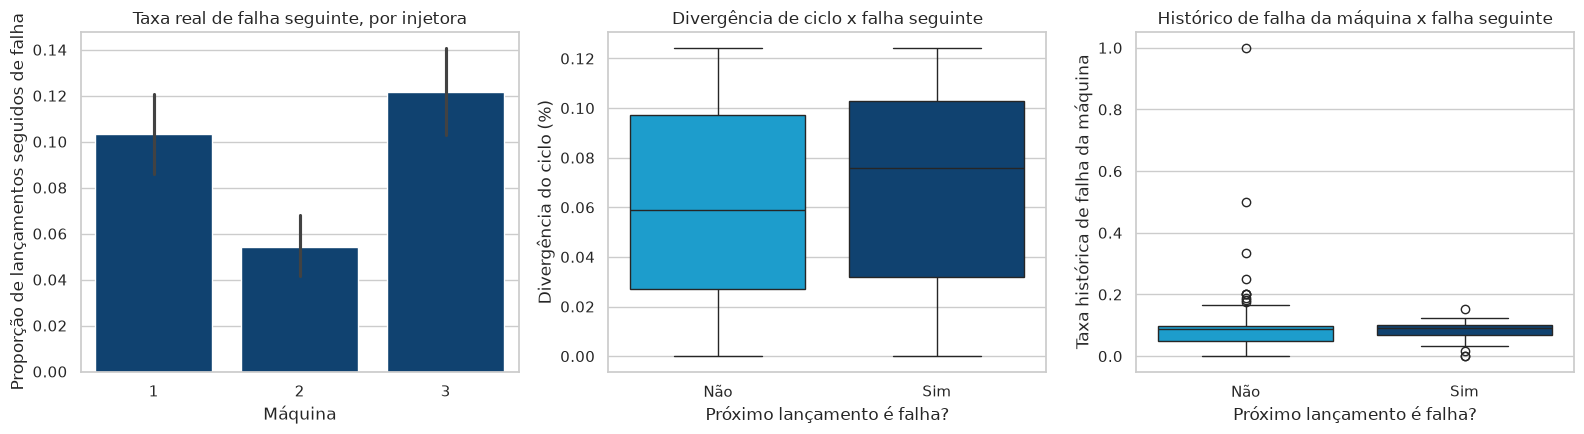

Taxa geral de 'próximo é falha' na base: 9.3 %


In [2]:
sns.set_theme(style="whitegrid")
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(data=df, x="numero_maquina", y="proximo_e_falha", estimator=np.mean, ax=eixos[0], color="#004380")
eixos[0].set_title("Taxa real de falha seguinte, por injetora")
eixos[0].set_ylabel("Propor\u00e7\u00e3o de lan\u00e7amentos seguidos de falha")
eixos[0].set_xlabel("M\u00e1quina")

sns.boxplot(data=df, x="proximo_e_falha", y="ciclo_divergencia_pct", ax=eixos[1], palette=["#00ABE9", "#004380"])
eixos[1].set_title("Diverg\u00eancia de ciclo x falha seguinte")
eixos[1].set_xlabel("Pr\u00f3ximo lan\u00e7amento \u00e9 falha?")
eixos[1].set_ylabel("Diverg\u00eancia do ciclo (%)")
eixos[1].set_xticklabels(["N\u00e3o", "Sim"])

sns.boxplot(data=df, x="proximo_e_falha", y="taxa_falha_historica_maquina", ax=eixos[2], palette=["#00ABE9", "#004380"])
eixos[2].set_title("Hist\u00f3rico de falha da m\u00e1quina x falha seguinte")
eixos[2].set_xlabel("Pr\u00f3ximo lan\u00e7amento \u00e9 falha?")
eixos[2].set_ylabel("Taxa hist\u00f3rica de falha da m\u00e1quina")
eixos[2].set_xticklabels(["N\u00e3o", "Sim"])

plt.tight_layout()
plt.show()

print("Taxa geral de 'pr\u00f3ximo \u00e9 falha' na base:", round(df["proximo_e_falha"].mean() * 100, 1), "%")

## Treino e avaliação

Mesmo algoritmo e features usados em `src/train.py` (a versão "oficial", executada via `python -m src.train` para gerar o artefato usado em produção) — aqui, com a matriz de confusão e a curva de importância de features exibidas visualmente, para documentar a análise.

📊 Relatório de classificação (conjunto de teste):

              precision    recall  f1-score   support

           0       0.93      0.62      0.75       642
           1       0.13      0.55      0.21        66

    accuracy                           0.61       708
   macro avg       0.53      0.58      0.48       708
weighted avg       0.86      0.61      0.70       708



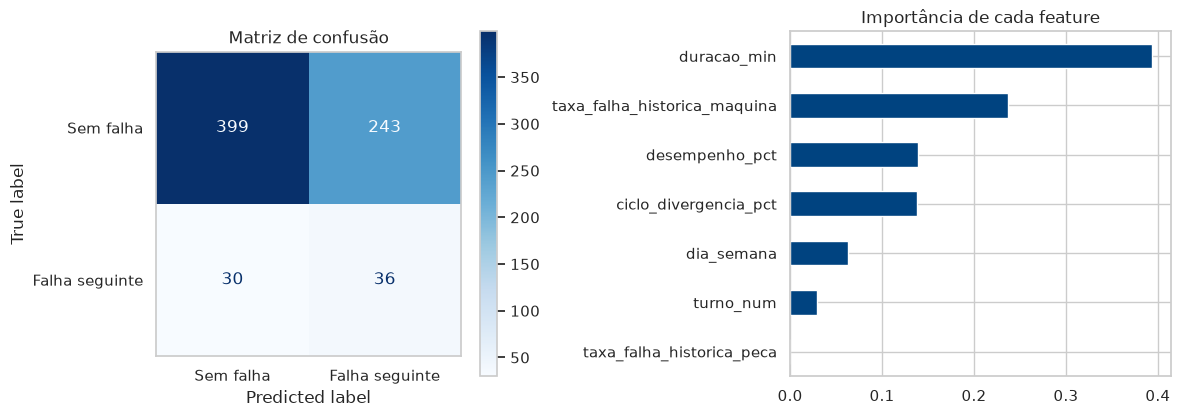

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

X = df[FEATURES]
y = df["proximo_e_falha"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() > 1 else None
)

modelo = RandomForestClassifier(
    n_estimators=150, max_depth=6, min_samples_leaf=5,
    random_state=42, class_weight="balanced",
)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
print("\U0001F4CA Relat\u00f3rio de classifica\u00e7\u00e3o (conjunto de teste):\n")
print(classification_report(y_test, y_pred, zero_division=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_estimator(
    modelo, X_test, y_test, cmap="Blues",
    display_labels=["Sem falha", "Falha seguinte"], ax=ax1,
)
ax1.set_title("Matriz de confus\u00e3o")
ax1.grid(False)

importancias = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values()
importancias.plot.barh(ax=ax2, color="#004380")
ax2.set_title("Import\u00e2ncia de cada feature")

plt.tight_layout()
plt.show()

## Salvando o modelo

O artefato oficial usado em produção é gerado por `python -m src.train` (não por este notebook) e salvo em `backend/app/ml_models/modelo_risco_parada.joblib` — dentro da pasta `backend/`, que os dois Dockerfiles do projeto já copiam para a imagem, garantindo que o modelo treinado seja carregado em qualquer ambiente (local ou produção). Este notebook é só o registro da análise exploratória; rodar esta célula é opcional, caso quiser salvar o modelo treinado aqui.

In [4]:
import joblib

caminho_modelos = os.path.abspath(os.path.join('..', '..', 'backend', 'app', 'ml_models'))
os.makedirs(caminho_modelos, exist_ok=True)
arquivo_modelo = os.path.join(caminho_modelos, 'modelo_risco_parada.joblib')

joblib.dump({"modelo": modelo, "features": FEATURES}, arquivo_modelo)
print(f"\u2705 Modelo salvo em: {arquivo_modelo}")

✅ Modelo salvo em: /home/claude/siamp/backend/app/ml_models/modelo_risco_parada.joblib
